# Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn
from sklearn .model_selection import train_test_split
import matplotlib.pyplot as plt
%matplotlib inline

# Линейная регрессия
from sklearn.linear_model import LinearRegression
from sklearn import metrics

#Регуляризация
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

#k-NN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

#Логистическая регрессия
from sklearn.linear_model import LogisticRegression

#SVM
from sklearn.svm import SVC

#Дерево решений
from sklearn.tree import DecisionTreeClassifier

#Случайный лес
from sklearn.ensemble import RandomForestClassifier

# Анализ данных

In [25]:
df = pd.read_csv('listings.csv')
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,3176,Fabulous Flat in great Location,3718,Britta,Pankow,Prenzlauer Berg Südwest,52.53471,13.41810,Entire home/apt,105.0,63,148,2023-05-25,0.81,1,272,0,First name and Last name: Nicolas Krotz <br/> ...
1,9991,Geourgeous flat - outstanding views,33852,Philipp,Pankow,Prenzlauer Berg Südwest,52.53269,13.41805,Entire home/apt,180.0,6,7,2020-01-04,0.06,1,32,0,03/Z/RA/003410-18
2,14325,Studio Apartment in Prenzlauer Berg,55531,Chris + Oliver,Pankow,Prenzlauer Berg Nordwest,52.54813,13.40366,Entire home/apt,70.0,150,26,2023-11-30,0.15,4,185,1,NaN
3,16644,In the Heart of Berlin - Kreuzberg,64696,Rene,Friedrichshain-Kreuzberg,nördliche Luisenstadt,52.50312,13.43508,Entire home/apt,90.0,93,48,2017-12-14,0.28,2,0,0,NaN
4,17904,Beautiful Kreuzberg studio - 3 months minimum,68997,Matthias,Neukölln,Reuterstraße,52.49419,13.42166,Entire home/apt,25.0,92,299,2022-12-01,1.71,1,1,0,NaN


## One-hot encoding

In [16]:
df = pd.get_dummies(df, columns=['neighbourhood_group', 'neighbourhood'])

df.head()

,id,name,host_id,host_name,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,...,neighbourhood_West 3,neighbourhood_West 4,neighbourhood_West 5,neighbourhood_Westend,neighbourhood_Wiesbadener Straße,neighbourhood_Wilhelmstadt,neighbourhood_Zehlendorf Nord,neighbourhood_Zehlendorf Südwest,neighbourhood_nördliche Luisenstadt,neighbourhood_südliche Luisenstadt
0,3176,Fabulous Flat in great Location,3718,Britta,52.53471,13.41810,Entire home/apt,105.0,63,148,...,False,False,False,False,False,False,False,False,False,False
1,9991,Geourgeous flat - outstanding views,33852,Philipp,52.53269,13.41805,Entire home/apt,180.0,6,7,...,False,False,False,False,False,False,False,False,False,False
2,14325,Studio Apartment in Prenzlauer Berg,55531,Chris + Oliver,52.54813,13.40366,Entire home/apt,70.0,150,26,...,False,False,False,False,False,False,False,False,False,False
3,16644,In the Heart of Berlin - Kreuzberg,64696,Rene,52.50312,13.43508,Entire home/apt,90.0,93,48,...,False,False,False,False,False,False,False,False,True,False
4,17904,Beautiful Kreuzberg studio - 3 months minimum,68997,Matthias,52.49419,13.42166,Entire home/apt,25.0,92,299,...,False,False,False,False,False,False,False,False,False,False


In [17]:
df = pd.read_csv('listings.csv')
df = pd.get_dummies(df, columns=['neighbourhood_group', 'neighbourhood'], drop_first=True)

df.head()

,id,name,host_id,host_name,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,...,neighbourhood_West 3,neighbourhood_West 4,neighbourhood_West 5,neighbourhood_Westend,neighbourhood_Wiesbadener Straße,neighbourhood_Wilhelmstadt,neighbourhood_Zehlendorf Nord,neighbourhood_Zehlendorf Südwest,neighbourhood_nördliche Luisenstadt,neighbourhood_südliche Luisenstadt
0,3176,Fabulous Flat in great Location,3718,Britta,52.53471,13.41810,Entire home/apt,105.0,63,148,...,False,False,False,False,False,False,False,False,False,False
1,9991,Geourgeous flat - outstanding views,33852,Philipp,52.53269,13.41805,Entire home/apt,180.0,6,7,...,False,False,False,False,False,False,False,False,False,False
2,14325,Studio Apartment in Prenzlauer Berg,55531,Chris + Oliver,52.54813,13.40366,Entire home/apt,70.0,150,26,...,False,False,False,False,False,False,False,False,False,False
3,16644,In the Heart of Berlin - Kreuzberg,64696,Rene,52.50312,13.43508,Entire home/apt,90.0,93,48,...,False,False,False,False,False,False,False,False,True,False
4,17904,Beautiful Kreuzberg studio - 3 months minimum,68997,Matthias,52.49419,13.42166,Entire home/apt,25.0,92,299,...,False,False,False,False,False,False,False,False,False,False


## Работа с пропусками

In [26]:
df.isnull().sum()

id                                   0
name                                 0
host_id                              0
host_name                            9
neighbourhood_group                  0
neighbourhood                        0
latitude                             0
longitude                            0
room_type                            0
price                             4938
minimum_nights                       0
number_of_reviews                    0
last_review                       3238
reviews_per_month                 3238
calculated_host_listings_count       0
availability_365                     0
number_of_reviews_ltm                0
license                           4956
dtype: int64

In [27]:
df['reviews_per_month'].fillna((df['reviews_per_month'].mean()), inplace=True)
df.isnull().sum()

C:\Users\melni\AppData\Local\Temp\ipykernel_18996\3301812625.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['reviews_per_month'].fillna((df['reviews_per_month'].mean()), inplace=True)


id                                   0
name                                 0
host_id                              0
host_name                            9
neighbourhood_group                  0
neighbourhood                        0
latitude                             0
longitude                            0
room_type                            0
price                             4938
minimum_nights                       0
number_of_reviews                    0
last_review                       3238
reviews_per_month                    0
calculated_host_listings_count       0
availability_365                     0
number_of_reviews_ltm                0
license                           4956
dtype: int64

In [32]:
df = pd.read_csv('listings.csv')
df['reviews_per_month'] = df['reviews_per_month'].fillna(df['reviews_per_month'].mode())
df.isnull().sum()

id                                   0
name                                 0
host_id                              0
host_name                            9
neighbourhood_group                  0
neighbourhood                        0
latitude                             0
longitude                            0
room_type                            0
price                             4938
minimum_nights                       0
number_of_reviews                    0
last_review                       3238
reviews_per_month                 3238
calculated_host_listings_count       0
availability_365                     0
number_of_reviews_ltm                0
license                           4956
dtype: int64

In [36]:
df = pd.read_csv('listings.csv')
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)
df['reviews_per_month'].isnull().sum()

np.int64(0)

In [ ]:
df.dropna(axis=0, how='any', thresh=None, subset=None, inplace=True)

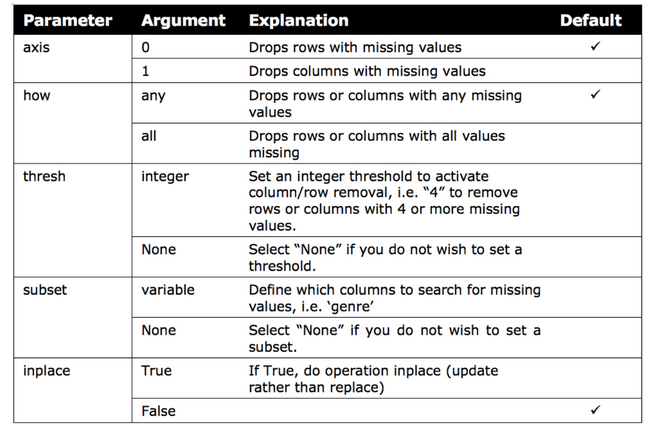

# Классические алгоритмы

## Разделение данных (train_test)

In [3]:
from sklearn .model_selection import train_test_split

In [4]:
df = pd.read_csv('advertising.csv')
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


In [7]:
X = df[['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage', 'Ad Topic Line', 'Country']]
y = df['Clicked on Ad']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=10, shuffle=True)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=10)

## Датасет

In [69]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
cancer = pd.DataFrame(cancer['data']) # type: ignore
cancer.head()

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [70]:
cancer = load_breast_cancer(return_X_y=True)
x = pd.DataFrame(cancer[0])

In [71]:
y = pd.DataFrame(cancer[1])

In [72]:
df = pd.concat([x, y], axis=1)

In [73]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,0
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [74]:
cancer2 = load_breast_cancer(return_X_y=True, as_frame=True)
display(cancer2)

(     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
 0          17.99         10.38          122.80     1001.0          0.11840   
 1          20.57         17.77          132.90     1326.0          0.08474   
 2          19.69         21.25          130.00     1203.0          0.10960   
 3          11.42         20.38           77.58      386.1          0.14250   
 4          20.29         14.34          135.10     1297.0          0.10030   
 ..           ...           ...             ...        ...              ...   
 564        21.56         22.39          142.00     1479.0          0.11100   
 565        20.13         28.25          131.20     1261.0          0.09780   
 566        16.60         28.08          108.30      858.1          0.08455   
 567        20.60         29.33          140.10     1265.0          0.11780   
 568         7.76         24.54           47.92      181.0          0.05263   
 
      mean compactness  mean concavity  mean conca

In [75]:
x = pd.DataFrame(cancer2[0])
y = pd.DataFrame(cancer2[1])
df = pd.concat([x, y], axis=1)
df

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0


In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [77]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


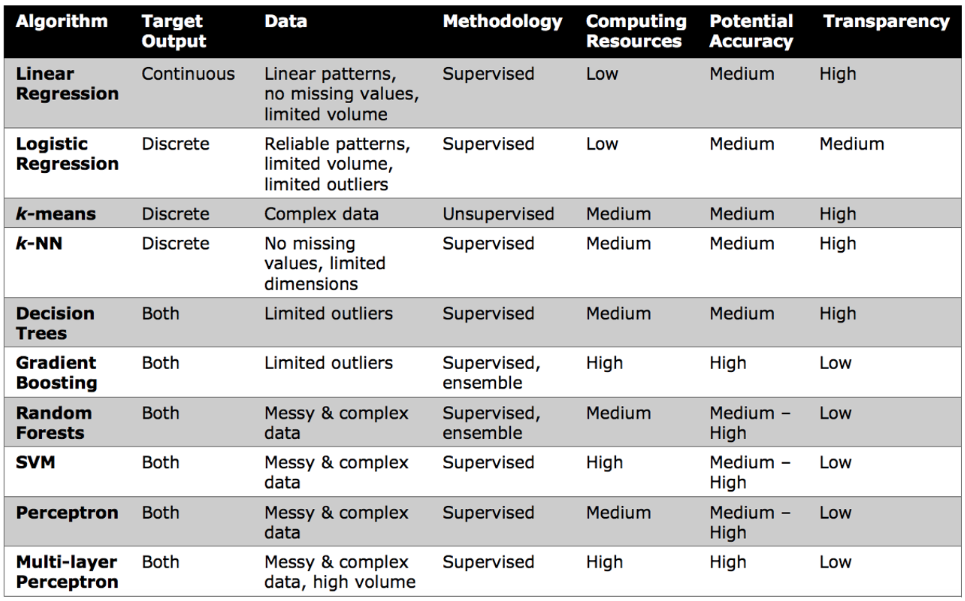

## Линейная регрессия 

In [56]:
df = pd.read_csv('Melbourne_housing_FULL.csv')
df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,68 Studley St,2,h,NaN,SS,Jellis,3/09/2016,2.5,3067.0,...,1.0,1.0,126.0,NaN,NaN,Yarra City Council,-37.8014,144.9958,Northern Metropolitan,4019.0
1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra City Council,-37.7996,144.9984,Northern Metropolitan,4019.0
2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra City Council,-37.8079,144.9934,Northern Metropolitan,4019.0
3,Abbotsford,18/659 Victoria St,3,u,NaN,VB,Rounds,4/02/2016,2.5,3067.0,...,2.0,1.0,0.0,NaN,NaN,Yarra City Council,-37.8114,145.0116,Northern Metropolitan,4019.0
4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra City Council,-37.8093,144.9944,Northern Metropolitan,4019.0


In [57]:
del df['Address']
del df['Method']
del df['SellerG']
del df['Date']
del df['Postcode']
del df['YearBuilt']
del df['Type']
del df['Lattitude']
del df['Longtitude']
del df['Regionname']
del df['Suburb']
del df ['CouncilArea']

print(df.head())

   Rooms      Price  Distance  Bedroom2  Bathroom  Car  Landsize  \
0      2        NaN       2.5       2.0       1.0  1.0     126.0   
1      2  1480000.0       2.5       2.0       1.0  1.0     202.0   
2      2  1035000.0       2.5       2.0       1.0  0.0     156.0   
3      3        NaN       2.5       3.0       2.0  1.0       0.0   
4      3  1465000.0       2.5       3.0       2.0  0.0     134.0   

   BuildingArea  Propertycount  
0           NaN         4019.0  
1           NaN         4019.0  
2          79.0         4019.0  
3           NaN         4019.0  
4         150.0         4019.0  


In [58]:
print(df.isnull().sum())

Rooms                0
Price             7610
Distance             1
Bedroom2          8217
Bathroom          8226
Car               8728
Landsize         11810
BuildingArea     21115
Propertycount        3
dtype: int64


In [59]:
df.shape

(34857, 9)

<Axes: >

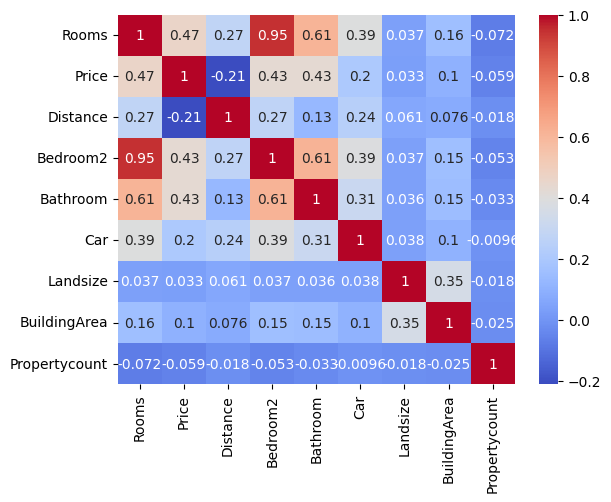

In [60]:
df_heat = df.corr()
sns.heatmap(df_heat,annot=True,cmap='coolwarm')

In [61]:
del df['Bedroom2']
del df['Landsize']
del df['Propertycount']

In [62]:
df.shape

(34857, 6)

In [63]:
del df['BuildingArea']
df['Car'] = df['Car'].fillna(df['Car'].mean())

df.dropna(axis=0, how='any', subset=None, inplace=True)

In [64]:
df.shape

(20800, 5)

In [65]:
X = df[['Rooms', 'Distance', 'Bathroom', 'Car']]
y = df['Price']

In [66]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=True, random_state=10)

In [67]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [68]:
model.intercept_

np.float64(282725.3156777328)

In [69]:
model.coef_

array([269450.10790037, -37787.76622417, 207173.05927097,  47417.17159475])

In [70]:
model_results = pd.DataFrame(model.coef_, X.columns, columns=['Coefficients'])
display(model_results)

,Coefficients
Rooms,269450.107900
Distance,-37787.766224
Bathroom,207173.059271
Car,47417.171595


In [71]:
new_house = pd.DataFrame({
    'Rooms': [2],
    'Distance': [2.5],
    'Bathroom': [1],
    'Car': [1]
})

In [72]:
new_house

,Rooms,Distance,Bathroom,Car
0,2,2.5,1,1


In [73]:
new_house_predict = model.predict(new_house)
print(new_house_predict)

[981746.34678377]


In [75]:
prediction = model.predict(X_test)
print(metrics.mean_absolute_error(y_test, prediction))

363782.9423236322


## Регуляризация

In [77]:
data = pd.read_csv('Melbourne_housing_FULL.csv')

In [79]:
#print(data.info())
#print(data.describe())

In [80]:
print(data.isnull().sum())

Suburb               0
Address              0
Rooms                0
Type                 0
Price             7610
Method               0
SellerG              0
Date                 0
Distance             1
Postcode             1
Bedroom2          8217
Bathroom          8226
Car               8728
Landsize         11810
BuildingArea     21115
YearBuilt        19306
CouncilArea          3
Lattitude         7976
Longtitude        7976
Regionname           3
Propertycount        3
dtype: int64


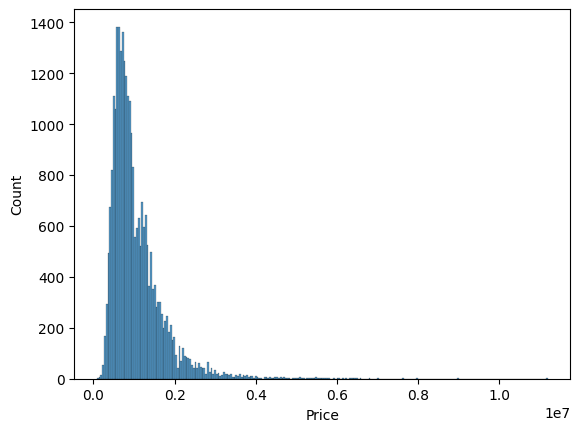

In [ ]:
sns.histplot(data['Price']) # type: ignore
plt.show()

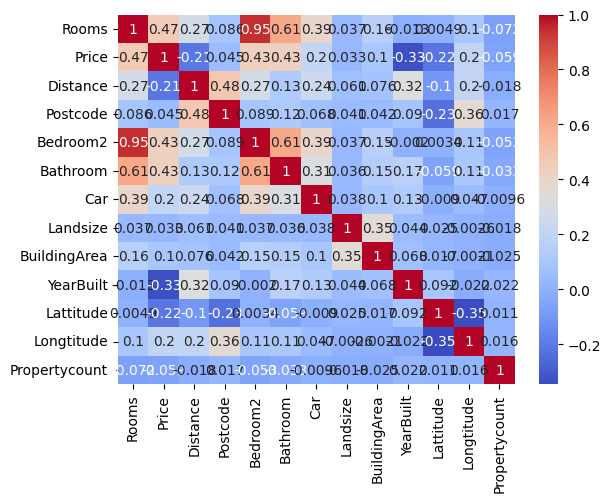

In [84]:
corr_matrix =data.select_dtypes(include=['number']).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

In [ ]:
# Удаление строк с пропущенными значениями
data_clean = data.dropna()

# Выбор нужных признаков для модели
features = ['Rooms', 'Bathroom', 'Landsize', 'BuildingArea', 'YearBuilt', 'Distance']
X = data_clean[features]
y = data_clean['Price']

# Преобразование категориальных переменных в числовые при необходимости
X = pd.get_dummies(X, drop_first=True)

In [86]:
X

,Rooms,Bathroom,Landsize,BuildingArea,YearBuilt,Distance
2,2,1.0,156.0,79.0,1900.0,2.5
4,3,2.0,134.0,150.0,1900.0,2.5
6,4,1.0,120.0,142.0,2014.0,2.5
11,3,2.0,245.0,210.0,1910.0,2.5
14,2,1.0,256.0,107.0,1890.0,2.5
...,...,...,...,...,...,...
34847,3,2.0,383.0,118.0,2016.0,25.5
34849,3,2.0,404.0,158.0,2012.0,25.5
34853,2,2.0,98.0,104.0,2018.0,6.3
34854,2,1.0,220.0,120.0,2000.0,6.3


In [87]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [89]:
X_train

,Rooms,Bathroom,Landsize,BuildingArea,YearBuilt,Distance
18721,4,2.0,542.0,170.0,1970.0,35.4
18577,3,2.0,313.0,140.0,1960.0,11.7
3461,3,1.0,178.0,120.0,2012.0,9.2
7947,2,1.0,88.0,121.0,2000.0,4.5
12940,3,1.0,338.0,132.0,1910.0,4.6
...,...,...,...,...,...,...
18426,1,1.0,0.0,35.0,1960.0,10.5
16741,4,2.0,425.0,140.0,1920.0,4.0
17443,3,2.0,548.0,127.0,1970.0,13.4
2686,3,1.0,544.0,160.0,1930.0,7.8


In [90]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [91]:
y_pred = ridge_model.predict(X_test_scaled)

In [92]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MSE: {mse}')
print(f'MAE: {mae}')
print(f'R^2: {r2}')

MSE: 177833788008.75238
MAE: 296309.9371352339
R^2: 0.5502475373400368


In [94]:
# Использование GridSearchCV
param_grid = {'alpha': [0.1, 1.0, 10.0, 100.0]}
grid_search = GridSearchCV(Ridge(), param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.1, 1.0, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter

In [95]:
print(f'Лучший параметр alpha: {grid_search.best_params_}')
best_ridge_model = grid_search.best_estimator_

Лучший параметр alpha: {'alpha': 100.0}


In [97]:
y_pred_best = best_ridge_model.predict(X_test_scaled)

mse_best = mean_squared_error(y_test, y_pred_best)
mae_best = mean_absolute_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print(f'Лучший MSE: {mse_best}')
print(f'Лучший MAE: {mae_best}')
print(f'Лучший R^2: {r2_best}')

Лучший MSE: 177770014041.41394
Лучший MAE: 295956.9822215604
Лучший R^2: 0.5504088255810691


## k-NN

In [7]:
df = pd.read_csv('advertising.csv')
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


In [8]:
del df ['Ad Topic Line']
del df ['Timestamp']
del df['Male']
del df ['Country']
del df ['City']

In [9]:
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Clicked on Ad
0,68.95,35,61833.90,256.09,0
1,80.23,31,68441.85,193.77,0
2,69.47,26,59785.94,236.50,0
3,74.15,29,54806.18,245.89,0
4,68.37,35,73889.99,225.58,0


In [16]:
df.shape

(1000, 5)

In [10]:
scaler = StandardScaler()
scaler.fit(df.drop('Clicked on Ad', axis=1))
scaled_features = scaler.transform(df.drop('Clicked on Ad', axis=1))

In [11]:
X = scaled_features
y = df['Clicked on Ad']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10, shuffle=True)

In [12]:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [15]:
model_predict = model.predict(X_test)

print(confusion_matrix(y_test, model_predict))
print(classification_report(y_test, model_predict))

[[144   2]
 [ 10 144]]
              precision    recall  f1-score   support

           0       0.94      0.99      0.96       146
           1       0.99      0.94      0.96       154

    accuracy                           0.96       300
   macro avg       0.96      0.96      0.96       300
weighted avg       0.96      0.96      0.96       300



In [21]:
display(pd.DataFrame(scaled_features[:10], columns=['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage']))

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage
0,0.249267,-0.114905,0.509691,1.734030
1,0.961132,-0.570425,1.002530,0.313805
2,0.282083,-1.139826,0.356949,1.287589
3,0.577432,-0.798185,-0.014456,1.501580
4,0.212664,-0.114905,1.408868,1.038731
5,-0.316187,-1.481466,0.355130,1.065166
6,1.508915,-0.342665,-0.085558,0.646300
7,0.063096,1.365536,-2.267813,-1.099355
8,0.601413,-0.684305,1.033866,0.945979
9,0.307958,-1.823106,0.047906,0.087053


In [27]:
model.predict(scaled_features)[0:10]

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0])

In [28]:
list(df[:10]['Clicked on Ad'])

[0, 0, 0, 0, 0, 0, 0, 1, 0, 0]

## Линейная классификация

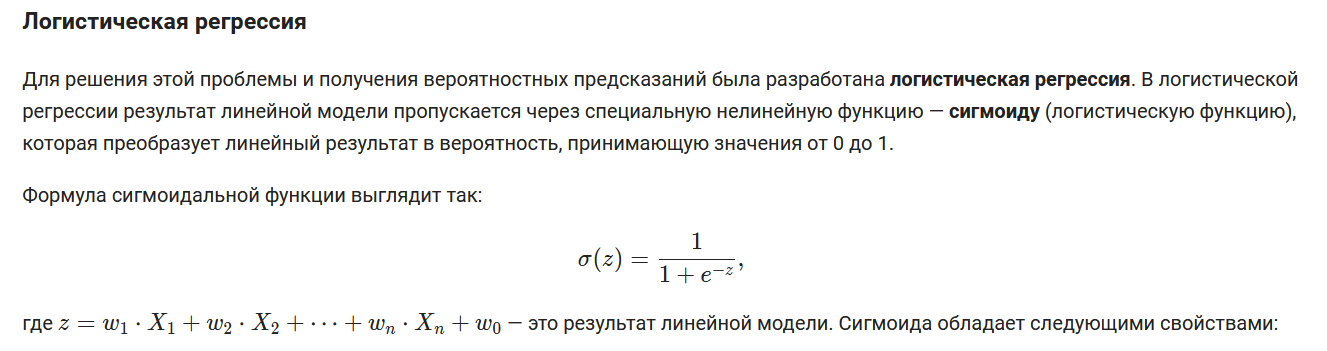

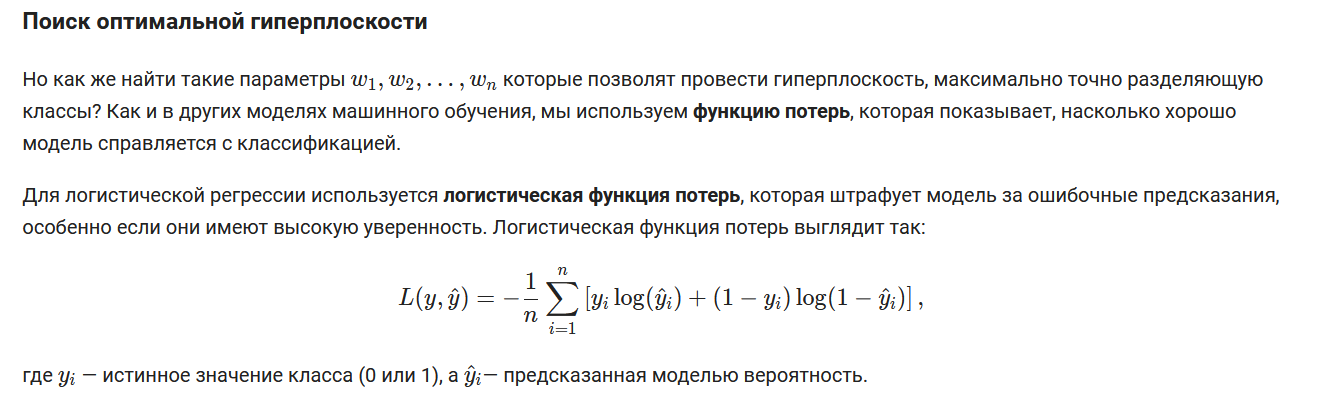

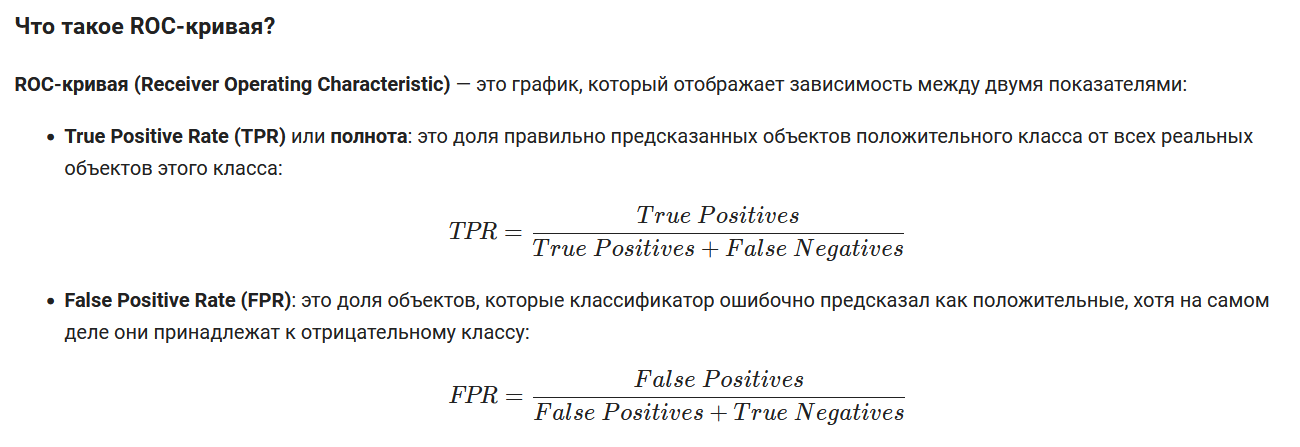

## Логистическая регрессия

In [84]:
df = pd.read_csv('18k_Projects.csv', dtype='unicode')
df.head()

,Id,Name,Url,State,Currency,Top Category,Category,Creator,Location,Updates,Comments,Rewards,Goal,Pledged,Backers,Start,End,Duration in Days,Facebook Connected,Facebook Friends,Facebook Shares,Has Video,Latitude,Longitude,Start Timestamp (UTC),End Timestamp (UTC),Creator Bio,Creator Website,Creator - # Projects Created,Creator - # Projects Backed,# Videos,# Images,# Words (Description),# Words (Risks and Challenges),# FAQs
0,1007121454,Nail Art and Photos Printed on your Nails w/ E...,https://www.kickstarter.com/projects/137019948...,failed,USD,Art,Art,Dodie Egolf,Puyallup,0,0,9,20000,6,2,2013/12/15,2014/01/14,30,Yes,272,70,Yes,47.1803951263,-122.2529029846,2013/12/15 01:53:49.000,2014/01/14 01:53:49.000,https://www.kickstarter.com/profile/1370199487,NaN,1,0,0,2,297,153,0
1,2032015036,Cold Again,https://www.kickstarter.com/projects/737783165...,failed,USD,Film & Video,Short Film,James Jacobs,Boston,0,0,8,3000,180,5,2013/12/15,2014/01/17,33,Yes,573,57,Yes,42.3323383331,-71.0456199646,2013/12/15 02:30:01.000,2014/01/17 02:30:01.000,https://www.kickstarter.com/profile/737783165,NaN,1,4,0,0,276,98,0
2,733782855,Uchu Bijin Jewelry,https://www.kickstarter.com/projects/uchubijin...,failed,USD,Fashion,Fashion,Uchu Bijin,New York,1,2,17,5000,1941,62,2013/12/15,2014/01/14,30,No,NaN,158,No,40.706577301,-73.8823738098,2013/12/15 01:29:42.000,2014/01/14 01:29:42.000,https://www.kickstarter.com/profile/858150887,http://uchubijin.com,2,2,0,12,1049,66,2
3,514687871,"Poetically Speaking: Stories of Love, Triumph ...",https://www.kickstarter.com/projects/tylicee/p...,failed,USD,Publishing,Poetry,Tylicee Mysreign,Detroit,0,0,4,5000,130,5,2013/12/15,2014/02/13,60,Yes,1285,2,Yes,42.3546390533,-83.1028404236,2013/12/15 01:12:28.000,2014/02/13 01:12:28.000,https://www.kickstarter.com/profile/1079088465,http://www.linkedin.com/pub/mys-reign/1a/469/4a8,1,2,0,0,309,169,0
4,683545993,Stranger Travels: Teachings from the Heart of ...,https://www.kickstarter.com/projects/197270300...,failed,USD,Publishing,Nonfiction,Ian Driscoll,Pucallpa,0,0,12,12000,1015,16,2013/12/15,2014/01/14,30,Yes,969,411,Yes,-8.43381,-74.55957,2013/12/15 01:17:46.000,2014/01/14 01:17:46.000,https://www.kickstarter.com/profile/1972703001,http://strangertravels.wordpress.com,1,0,0,6,1636,216,0


In [85]:
del df ['Id']
del df ['Name']
del df ['Url']
del df ['Location']
del df ['Pledged']
del df ['Creator']
del df ['Category']
del df ['Updates']
del df ['Start']
del df ['End']
del df ['Latitude']
del df ['Longitude']
del df ['Start Timestamp (UTC)']
del df ['End Timestamp (UTC)']
del df ['Creator Bio']
del df ['Creator Website']

In [86]:
df.shape

(18142, 19)

In [87]:
df.head()

,State,Currency,Top Category,Comments,Rewards,Goal,Backers,Duration in Days,Facebook Connected,Facebook Friends,Facebook Shares,Has Video,Creator - # Projects Created,Creator - # Projects Backed,# Videos,# Images,# Words (Description),# Words (Risks and Challenges),# FAQs
0,failed,USD,Art,0,9,20000,2,30,Yes,272,70,Yes,1,0,0,2,297,153,0
1,failed,USD,Film & Video,0,8,3000,5,33,Yes,573,57,Yes,1,4,0,0,276,98,0
2,failed,USD,Fashion,2,17,5000,62,30,No,NaN,158,No,2,2,0,12,1049,66,2
3,failed,USD,Publishing,0,4,5000,5,60,Yes,1285,2,Yes,1,2,0,0,309,169,0
4,failed,USD,Publishing,0,12,12000,16,30,Yes,969,411,Yes,1,0,0,6,1636,216,0


In [88]:
df = pd.get_dummies(df, columns=['State', 'Currency', 'Top Category', 'Facebook Connected', 'Has Video'],
                    drop_first=True)
df.head()

,Comments,Rewards,Goal,Backers,Duration in Days,Facebook Friends,Facebook Shares,Creator - # Projects Created,Creator - # Projects Backed,# Videos,# Images,# Words (Description),# Words (Risks and Challenges),# FAQs,State_successful,Currency_CAD,Currency_EUR,Currency_GBP,Currency_NZD,Currency_USD,Top Category_Comics,Top Category_Crafts,Top Category_Dance,Top Category_Design,Top Category_Fashion,Top Category_Film & Video,Top Category_Food,Top Category_Games,Top Category_Journalism,Top Category_Music,Top Category_Photography,Top Category_Publishing,Top Category_Technology,Top Category_Theater,Facebook Connected_Yes,Has Video_Yes
0,0,9,20000,2,30,272,70,1,0,0,2,297,153,0,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True
1,0,8,3000,5,33,573,57,1,4,0,0,276,98,0,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,True
2,2,17,5000,62,30,NaN,158,2,2,0,12,1049,66,2,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
3,0,4,5000,5,60,1285,2,1,2,0,0,309,169,0,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,True
4,0,12,12000,16,30,969,411,1,0,0,6,1636,216,0,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,True


In [89]:
df.shape

(18142, 36)

In [90]:
df.isnull().sum()

Comments                             0
Rewards                              0
Goal                                 0
Backers                              0
Duration in Days                     0
Facebook Friends                  5852
Facebook Shares                      0
Creator - # Projects Created         0
Creator - # Projects Backed       4244
# Videos                           101
# Images                             0
# Words (Description)                0
# Words (Risks and Challenges)     101
# FAQs                               0
State_successful                     0
Currency_CAD                         0
Currency_EUR                         0
Currency_GBP                         0
Currency_NZD                         0
Currency_USD                         0
Top Category_Comics                  0
Top Category_Crafts                  0
Top Category_Dance                   0
Top Category_Design                  0
Top Category_Fashion                 0
Top Category_Film & Video

In [91]:
print(df['State_successful'].corr(df['Facebook Friends'].astype('float')))
print(df['State_successful'].corr(df['Creator - # Projects Backed'].astype('float')))
print(df['State_successful'].corr(df['# Videos'].astype('float')))
print(df['State_successful'].corr(df['# Words (Risks and Challenges)'].astype('float')))

0.1595402478497283
0.1062497398558676
0.05657919078430435
0.0075448605697678185


In [92]:
df.dropna(subset=['# Videos'], inplace=True)

In [93]:
df.isnull().sum()

Comments                             0
Rewards                              0
Goal                                 0
Backers                              0
Duration in Days                     0
Facebook Friends                  5826
Facebook Shares                      0
Creator - # Projects Created         0
Creator - # Projects Backed       4244
# Videos                             0
# Images                             0
# Words (Description)                0
# Words (Risks and Challenges)       0
# FAQs                               0
State_successful                     0
Currency_CAD                         0
Currency_EUR                         0
Currency_GBP                         0
Currency_NZD                         0
Currency_USD                         0
Top Category_Comics                  0
Top Category_Crafts                  0
Top Category_Dance                   0
Top Category_Design                  0
Top Category_Fashion                 0
Top Category_Film & Video

In [94]:
# del df['# Words (Risks and Challenges)'] Не нужно, так как 'df.dropna(subset=['# Videos'], inplace=True)' всё удалил

In [95]:
df.shape

(18041, 36)

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18041 entries, 0 to 18141
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Comments                        18041 non-null  object
 1   Rewards                         18041 non-null  object
 2   Goal                            18041 non-null  object
 3   Backers                         18041 non-null  object
 4   Duration in Days                18041 non-null  object
 5   Facebook Friends                12215 non-null  object
 6   Facebook Shares                 18041 non-null  object
 7   Creator - # Projects Created    18041 non-null  object
 8   Creator - # Projects Backed     13797 non-null  object
 9   # Videos                        18041 non-null  object
 10  # Images                        18041 non-null  object
 11  # Words (Description)           18041 non-null  object
 12  # Words (Risks and Challenges)  18041 non-null  obj

In [97]:
df.describe()

,Comments,Rewards,Goal,Backers,Duration in Days,Facebook Friends,Facebook Shares,Creator - # Projects Created,Creator - # Projects Backed,# Videos,# Images,# Words (Description),# Words (Risks and Challenges),# FAQs,State_successful,Currency_CAD,Currency_EUR,Currency_GBP,Currency_NZD,Currency_USD,Top Category_Comics,Top Category_Crafts,Top Category_Dance,Top Category_Design,Top Category_Fashion,Top Category_Film & Video,Top Category_Food,Top Category_Games,Top Category_Journalism,Top Category_Music,Top Category_Photography,Top Category_Publishing,Top Category_Technology,Top Category_Theater,Facebook Connected_Yes,Has Video_Yes
count,18041,18041,18041,18041,18041,12215,18041,18041,13797,18041,18041,18041,18041,18041,18041,18041,18041,18041,18041,18041,18041,18041,18041,18041,18041,18041,18041,18041,18041,18041,18041,18041,18041,18041,18041,18041
unique,462,66,1123,1150,60,2367,1954,26,125,18,93,2422,600,33,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
top,0,8,5000,1,30,0,0,1,0,0,0,294,74,0,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True
freq,9712,1791,1351,1195,7144,110,1368,14049,4661,16034,6465,42,149,14394,9053,17148,17979,15749,17950,14256,17472,17821,17778,16599,17015,14586,16937,16423,17968,15329,17505,16003,17057,17396,12215,14973


C:\Users\melni\AppData\Local\Temp\ipykernel_17052\829702782.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Facebook Friends'], kde=True, hist=False)


<Axes: xlabel='Facebook Friends', ylabel='Density'>

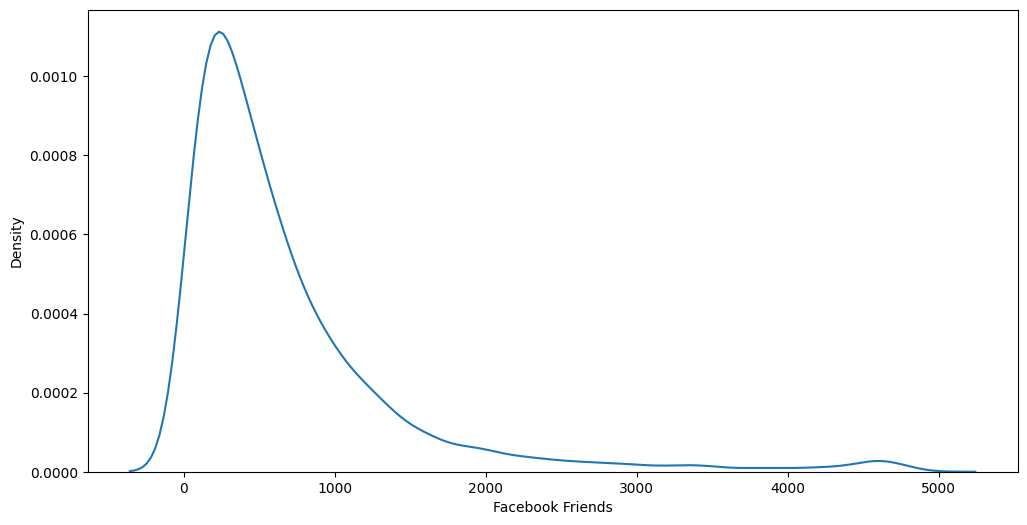

In [98]:
plt.figure(figsize=(12,6))
sns.distplot(df['Facebook Friends'], kde=True, hist=False)

C:\Users\melni\AppData\Local\Temp\ipykernel_17052\4242053956.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Creator - # Projects Backed'], kde=True, hist=False)


<Axes: xlabel='Creator - # Projects Backed', ylabel='Density'>

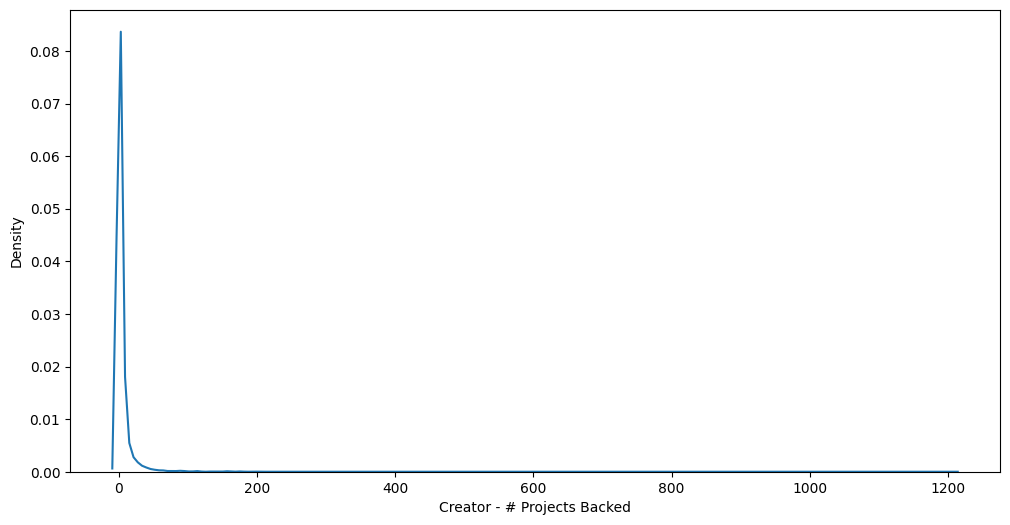

In [99]:
plt.figure(figsize=(12,6))
sns.distplot(df['Creator - # Projects Backed'], kde=True, hist=False)

In [100]:
df['Creator - # Projects Backed'] = df['Creator - # Projects Backed'].fillna(df['Creator - # Projects Backed'].astype(float).mean())

In [101]:
df.dropna(subset=['Facebook Friends'], inplace=True)

In [103]:
df.isnull().sum().sum()

np.int64(0)

In [104]:
df.shape

(12215, 36)

In [105]:
X = df.drop('State_successful', axis=1)
y = df['State_successful']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10, shuffle=True)

In [108]:
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

c:\Workspaces\ML\ML courses\.env\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 10000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=10000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [ ]:
new_project = [
    0, #Comments
    9, #Rewards
    2500, #Goal
    157, #Backers
    31, #Duration in Days
    319, #Facebook Friends
    110, #Facebook Shares
    1, #Creator - # Projects Created
    0, #Creator - # Projects Backed
    0, ## Videos
    12, ## Images
    872, ## Words (Description)
    65, ## Words (Risks and Challenges)
    0, ## FAQs
    0, #Currency_AUD
    1, #Currency_CAD
    0, #Currency_EUR
    0, #Currency_GBP
    0, #Currency_NZD
    0, #Currency_USD
    0, #Top Category_Art
    0, #Top Category_Comics
    0, #Top Category_Crafts
    0, #Top Category_Dance
    0, #Top Category_Design
    0, #Top Category_Fashion
    1, #Top Category_Film & Video
    0, #Top Category_Food
    0, #Top Category_Games
    0, #Top Category_Journalism
    0, #Top Category_Music
    0, #Top Category_Photography
    0, #Top Category_Publishing
    0, #Top Category_Technology
    0, #Top Category_Theater
    #0, #Facebook Connected_No
    #0, #Facebook Connected_Yes
    #0, #Has Video_No
    #1, #Has Video_Yes
]
new_pred = model.predict([new_project])
print(new_pred)
# [1]

[ True]


c:\Workspaces\ML\ML courses\.env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [113]:
model_predict = model.predict(X_test)

print(confusion_matrix(y_test, model_predict))
print(classification_report(y_test, model_predict))

[[1615  214]
 [ 233 1603]]
              precision    recall  f1-score   support

       False       0.87      0.88      0.88      1829
        True       0.88      0.87      0.88      1836

    accuracy                           0.88      3665
   macro avg       0.88      0.88      0.88      3665
weighted avg       0.88      0.88      0.88      3665



## SVM (Support vector machine)

In [132]:
df = pd.read_csv('advertising.csv')
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


In [133]:
df['City'].value_counts()

City
Lisamouth        3
Williamsport     3
West Amanda      2
East Timothy     2
Lake Patrick     2
                ..
Nicholasland     1
Duffystad        1
New Darlene      1
South Jessica    1
Lake Matthew     1
Name: count, Length: 969, dtype: int64

In [134]:
del df ['Ad Topic Line']
del df ['Timestamp']

In [135]:
df = pd.get_dummies(df, columns=['Country', 'City'])

In [136]:
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad,Country_Afghanistan,Country_Albania,Country_Algeria,Country_American Samoa,Country_Andorra,Country_Angola,Country_Anguilla,Country_Antarctica (the territory South of 60 deg S),Country_Antigua and Barbuda,Country_Argentina,Country_Armenia,Country_Aruba,Country_Australia,Country_Austria,Country_Azerbaijan,Country_Bahamas,Country_Bahrain,Country_Bangladesh,Country_Barbados,Country_Belarus,Country_Belgium,Country_Belize,Country_Benin,Country_Bermuda,Country_Bhutan,Country_Bolivia,Country_Bosnia and Herzegovina,Country_Bouvet Island (Bouvetoya),Country_Brazil,Country_British Indian Ocean Territory (Chagos Archipelago),Country_British Virgin Islands,Country_Brunei Darussalam,Country_Bulgaria,Country_Burkina Faso,...,City_West Russell,City_West Ryan,City_West Samantha,City_West Shannon,City_West Sharon,City_West Shaun,City_West Steven,City_West Sydney,City_West Tanner,City_West Tanya,City_West Terrifurt,City_West Thomas,City_West Tinashire,City_West Travismouth,City_West Wendyland,City_West William,City_West Zacharyborough,City_Westshire,City_Whiteport,City_Whitneyfort,City_Wilcoxport,City_Williammouth,City_Williamport,City_Williamsborough,City_Williamsfort,City_Williamsmouth,City_Williamsport,City_Williamsside,City_Williamstad,City_Wilsonburgh,City_Wintersfort,City_Wongland,City_Wrightburgh,City_Wrightview,City_Yangside,City_Youngburgh,City_Youngfort,City_Yuton,City_Zacharystad,City_Zacharyton
0,68.95,35,61833.90,256.09,0,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
1,80.23,31,68441.85,193.77,1,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,69.47,26,59785.94,236.50,0,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,74.15,29,54806.18,245.89,1,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,68.37,35,73889.99,225.58,0,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [137]:
X = df.drop('Clicked on Ad', axis=1)
y = df['Clicked on Ad']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10, shuffle=True)

In [138]:
model = SVC()
model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [140]:
model_predict = model.predict(X_test)

print(confusion_matrix(y_test, model_predict))
print(classification_report(y_test, model_predict))

[[124  22]
 [ 68  86]]
              precision    recall  f1-score   support

           0       0.65      0.85      0.73       146
           1       0.80      0.56      0.66       154

    accuracy                           0.70       300
   macro avg       0.72      0.70      0.70       300
weighted avg       0.72      0.70      0.69       300



In [141]:
hyperparameters = {'C': [10, 25, 50], 'gamma': [0.001, 0.0001, 0.00001]}

In [142]:
grid = GridSearchCV(SVC(), hyperparameters)
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [10, 25, ...], 'gamma': [0.001, 0.0001, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate par

In [143]:
grid.best_params_

{'C': 50, 'gamma': 1e-05}

In [144]:
grid_predictions = grid.predict(X_test)

print(confusion_matrix(y_test, grid_predictions))
print(classification_report(y_test, grid_predictions))

[[129  17]
 [ 15 139]]
              precision    recall  f1-score   support

           0       0.90      0.88      0.89       146
           1       0.89      0.90      0.90       154

    accuracy                           0.89       300
   macro avg       0.89      0.89      0.89       300
weighted avg       0.89      0.89      0.89       300



# Trees, Forests, etc.

## Введения в леса

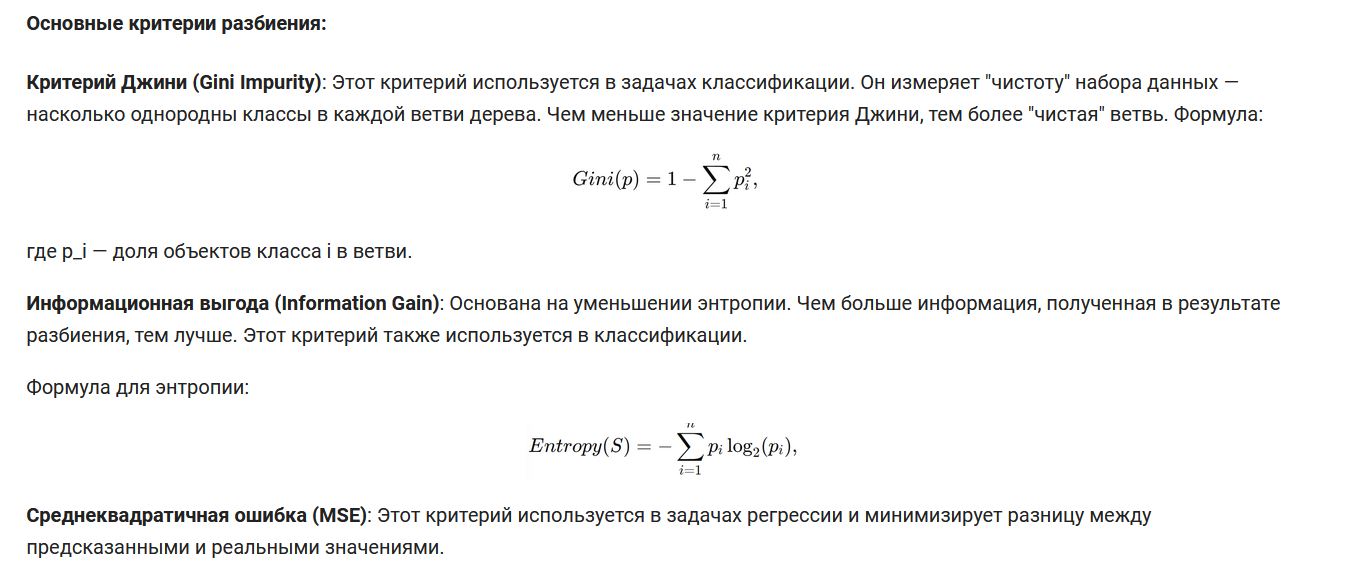

In [4]:
# tree = DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, min_samples_split=20, random_state=42)
# tree.fit(X_train, y_train)

In [ ]:
# param_grid = {'ccp_alpha': [0.001, 0.01, 0.1, 0.5]}
# tree = DecisionTreeClassifier(random_state=42)

# grid_search = GridSearchCV(tree, param_grid, cv=5)
# grid_search.fit(X_train, y_train)

# best_tree = grid_search.best_estimator_

In [5]:
df = pd.read_csv('advertising.csv')
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


In [7]:
df = pd.get_dummies(df, columns=['Country', 'City'])

In [9]:
del df['Ad Topic Line']
del df['Timestamp']

In [11]:
print(df.head())
df.head()

   Daily Time Spent on Site  Age  ...  City_Zacharystad  City_Zacharyton
0                     68.95   35  ...             False            False
1                     80.23   31  ...             False            False
2                     69.47   26  ...             False            False
3                     74.15   29  ...             False            False
4                     68.37   35  ...             False            False

[5 rows x 1212 columns]


,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad,Country_Afghanistan,Country_Albania,Country_Algeria,Country_American Samoa,Country_Andorra,Country_Angola,Country_Anguilla,Country_Antarctica (the territory South of 60 deg S),Country_Antigua and Barbuda,Country_Argentina,Country_Armenia,Country_Aruba,Country_Australia,Country_Austria,Country_Azerbaijan,Country_Bahamas,Country_Bahrain,Country_Bangladesh,Country_Barbados,Country_Belarus,Country_Belgium,Country_Belize,Country_Benin,Country_Bermuda,Country_Bhutan,Country_Bolivia,Country_Bosnia and Herzegovina,Country_Bouvet Island (Bouvetoya),Country_Brazil,Country_British Indian Ocean Territory (Chagos Archipelago),Country_British Virgin Islands,Country_Brunei Darussalam,Country_Bulgaria,Country_Burkina Faso,...,City_West Russell,City_West Ryan,City_West Samantha,City_West Shannon,City_West Sharon,City_West Shaun,City_West Steven,City_West Sydney,City_West Tanner,City_West Tanya,City_West Terrifurt,City_West Thomas,City_West Tinashire,City_West Travismouth,City_West Wendyland,City_West William,City_West Zacharyborough,City_Westshire,City_Whiteport,City_Whitneyfort,City_Wilcoxport,City_Williammouth,City_Williamport,City_Williamsborough,City_Williamsfort,City_Williamsmouth,City_Williamsport,City_Williamsside,City_Williamstad,City_Wilsonburgh,City_Wintersfort,City_Wongland,City_Wrightburgh,City_Wrightview,City_Yangside,City_Youngburgh,City_Youngfort,City_Yuton,City_Zacharystad,City_Zacharyton
0,68.95,35,61833.90,256.09,0,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
1,80.23,31,68441.85,193.77,1,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,69.47,26,59785.94,236.50,0,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,74.15,29,54806.18,245.89,1,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,68.37,35,73889.99,225.58,0,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [12]:
X = df.drop('Clicked on Ad', axis=1)
y = df['Clicked on Ad']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10, shuffle=True)

In [13]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [14]:
model_predict = model.predict(X_test)
print(confusion_matrix(y_test, model_predict))
print(classification_report(y_test, model_predict))

[[139   7]
 [  8 146]]
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       146
           1       0.95      0.95      0.95       154

    accuracy                           0.95       300
   macro avg       0.95      0.95      0.95       300
weighted avg       0.95      0.95      0.95       300



## Random forest

In [6]:
df = pd.read_csv('advertising.csv')
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 00:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 01:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 02:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 03:36:18,0


In [7]:
del df['Ad Topic Line']
del df['Timestamp']

In [8]:
df = pd.get_dummies(df, columns=['City', 'Country'])

In [9]:
X = df.drop('Clicked on Ad', axis=1)
y = df['Clicked on Ad']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10, shuffle=True)

In [10]:
model = RandomForestClassifier(n_estimators=150)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [11]:
model_predict = model.predict(X_test)

print(confusion_matrix(y_test, model_predict))
print(classification_report(y_test, model_predict))

[[141   5]
 [  7 147]]
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       146
           1       0.97      0.95      0.96       154

    accuracy                           0.96       300
   macro avg       0.96      0.96      0.96       300
weighted avg       0.96      0.96      0.96       300

